# NeuralKit Interactive Demo
A lightweight, zero-dependency neural network framework built strictly from scratch in Python using only NumPy.

In [14]:
!pip install neuralkit -q

## 1. XOR Classification
Training a 2-layer Neural Network to solve the non-linear XOR problem.

In [15]:
import numpy as np
from neuralkit import Sequential, Dense, Sigmoid, MSELoss, SGD, Trainer

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float64)
y = np.array([[0], [1], [1], [0]], dtype=np.float64)

model = Sequential([
    Dense(2, 8, activation=Sigmoid()),
    Dense(8, 1, activation=Sigmoid()),
])

trainer = Trainer(model, SGD(lr=2.0), MSELoss())
history = trainer.fit(X, y, epochs=2000, verbose=0)

print('Predictions:')
for i in range(4):
    pred = model.predict(X[i:i+1])
    print(f'  {X[i]} -> {pred[0][0]:.4f} (expected {y[i][0]})')

Predictions:
  [0. 0.] -> 0.0203 (expected 0.0)
  [0. 1.] -> 0.9764 (expected 1.0)
  [1. 0.] -> 0.9742 (expected 1.0)
  [1. 1.] -> 0.0295 (expected 0.0)


## 2. Training Loss Curve
Visualizing training progression over epochs.

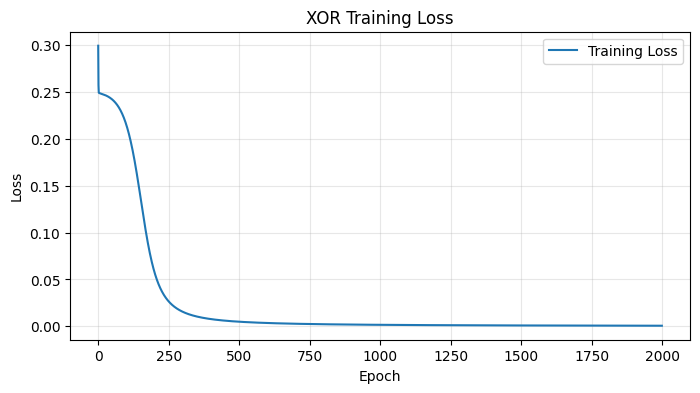

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(history['loss'], label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('XOR Training Loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 3. Iris Multi-Class Classification
Classifying Iris flower dataset using MLP with ReLU and Softmax Cross Entropy.

In [17]:
from sklearn.datasets import load_iris
import numpy as np
from neuralkit import Sequential, Dense, ReLU, Adam, Trainer
from neuralkit.losses import SoftmaxCrossEntropy
from neuralkit.data import train_test_split
from neuralkit.data.transforms import StandardScaler, OneHotEncoder
from neuralkit.metrics import accuracy, classification_report

# Load and preprocess dataset
iris = load_iris()
X, y = iris.data.astype(np.float64), iris.target

scaler = StandardScaler()
X = scaler.fit_transform(X)

encoder = OneHotEncoder()
y_onehot = encoder.fit_transform(y)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_seed=42)

# Build Model
model = Sequential([
    Dense(4, 16, activation=ReLU()),
    Dense(16, 8, activation=ReLU()),
    Dense(8, 3),
])

# Train with Adam
trainer = Trainer(model, Adam(lr=0.01), SoftmaxCrossEntropy())
history = trainer.fit(X_train, y_train, epochs=200, verbose=0)

# Evaluate model
preds = model.predict(X_test)
y_pred = np.argmax(preds, axis=1)
y_true = np.argmax(y_test, axis=1)

print(f'Test Accuracy: {accuracy(y_true, y_pred):.1%}\n')
print(classification_report(y_true, y_pred))

Test Accuracy: 93.3%

              precision     recall   f1-score    support

           0     1.0000     0.8571     0.9231          7
           1     0.8462     1.0000     0.9167         11
           2     1.0000     0.9167     0.9565         12

    accuracy                           0.9333         30
   macro avg     0.9487     0.9246     0.9321         30


## 4. Model Serialization (Save & Load)
Saving trained model architecture (JSON) and weights (.npz) to disk and reloading.

In [21]:
from neuralkit.model import Sequential

# Save model
model.save('iris_model.nk')
print('Model saved to iris_model.nk')

# Load model and verify predictions match
loaded = Sequential.load('iris_model.nk')
loaded_preds = loaded.predict(X_test)
print(f'Predictions match: {np.allclose(preds, loaded_preds)}')

Model saved to iris_model.nk
Predictions match: True


---
**GitHub Repository:** [14k5hy4/neuralkit](https://github.com/14k5hy4/neuralkit)  
**PyPI Package:** [neuralkit](https://pypi.org/project/neuralkit/)